## Graph-1 

In [112]:
from typing import TypedDict, List
from langgraph.graph import StateGraph

In [113]:
class AgentState(TypedDict):
    values: List[int]
    name: str
    result: str 
    

In [114]:
def process_values(state: AgentState) -> AgentState:
    """This function processes multiple different inputs."""
    print(state) # state before processing
    state["result"] = f"Hi there {state['name']} Your sum = {sum(state['values'])}"
    print(state) # state after processing
    return state


In [115]:
graph = StateGraph(AgentState)
graph.add_node("processor", process_values)
graph.set_entry_point("processor")
graph.set_finish_point("processor")
app = graph.compile()

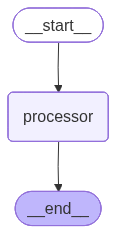

In [116]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [117]:
answer = app.invoke({"values": [1,2,3], "name": "Alice"})

{'values': [1, 2, 3], 'name': 'Alice'}
{'values': [1, 2, 3], 'name': 'Alice', 'result': 'Hi there Alice Your sum = 6'}


In [118]:
answer

{'values': [1, 2, 3], 'name': 'Alice', 'result': 'Hi there Alice Your sum = 6'}

In [119]:
answer["result"]

'Hi there Alice Your sum = 6'

## Graph-2: Practice exercise

In [120]:
from typing import TypedDict, List
from langgraph.graph import StateGraph

In [121]:
class AgentState(TypedDict):
    values: List[int]
    operation: str
    result: str

In [122]:
def process_values(state: AgentState) -> AgentState:
    # Example processing function that multiplies the values and updates the result
    if state["operation"] == "*":
        product = 1
        for value in state["values"]:
            product *= value
        state["result"] = f"The product of {state['values']} is {product}"
        return state 
    elif state["operation"] == "+":
        total = sum(state["values"])
        state["result"] = f"The sum of {state['values']} is {total}"
        return state
    elif state["operation"] == "-":
        difference = state["values"][0]
        for value in state["values"][1:]:
            difference -= value
        state["result"] = f"The difference of {state['values']} is {difference}"
        return state
    elif state["operation"] == "/":
        quotient = state["values"][0]
        for value in state["values"][1:]:
            quotient /= value
        state["result"] = f"The quotient of {state['values']} is {quotient}"
        return state
    else:
        raise ValueError(f"Unsupported operation: {state['operation']}")

In [123]:
graph = StateGraph(AgentState)
graph.add_node("processor", process_values)
graph.set_entry_point("processor")
graph.set_finish_point("processor")
app = graph.compile()

In [124]:
answer = app.invoke({"values": [1, 2, 3], "operation": "+"})

In [125]:
answer

{'values': [1, 2, 3], 'operation': '+', 'result': 'The sum of [1, 2, 3] is 6'}

In [126]:
answer = app.invoke({"values": [1,2,3], "operation": "*"})

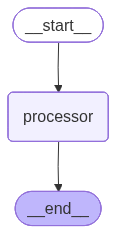

In [127]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

## Graph 3

In [128]:
from typing import TypedDict, List
from langgraph.graph import StateGraph

In [129]:
class AgentState(TypedDict):
    name: str
    age: str
    final: str

In [ ]:
def first_node(state: AgentState) -> AgentState:
    """This is the first node of our sequence"""
    state["final"] = f"Hello {state['name']}"
    print(state) # state after first node
    return state

def second_node(state: AgentState) -> AgentState:
    """This is the second node of our sequence"""
    state["final"] += f", you are {state['age']} years old." # here we are appending to the final result from the first node
    print(state) # state after second node
    return state


In [ ]:
graph = StateGraph(AgentState)

graph.add_node("first", first_node)
graph.add_node("second", second_node)
graph.set_entry_point("first")
graph.add_edge("first", "second") # this edge connects the first node to the second node, allowing the state to flow from the first to the second
graph.set_finish_point("second")
app = graph.compile()

In [132]:
app.invoke({"name": "Alice", "age": "45"})

{'name': 'Alice', 'age': '45', 'final': 'Hello Alice'}
{'name': 'Alice', 'age': '45', 'final': 'Hello Alice, you are 45 years old.'}


{'name': 'Alice', 'age': '45', 'final': 'Hello Alice, you are 45 years old.'}

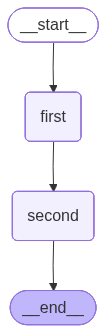

In [133]:
app